<a href="https://colab.research.google.com/github/orelebile/Coursera-test/blob/main/project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


df=pd.read_csv('/content/CSEdata.csv')

#df.shape
df.columns
df.head ()


,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1


In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252000 entries, 0 to 251999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Id                 252000 non-null  int64 
 1   Income             252000 non-null  int64 
 2   Age                252000 non-null  int64 
 3   Experience         252000 non-null  int64 
 4   Married/Single     252000 non-null  object
 5   House_Ownership    252000 non-null  object
 6   Car_Ownership      252000 non-null  object
 7   Profession         252000 non-null  object
 8   CITY               252000 non-null  object
 9   STATE              252000 non-null  object
 10  CURRENT_JOB_YRS    252000 non-null  int64 
 11  CURRENT_HOUSE_YRS  252000 non-null  int64 
 12  Risk_Flag          252000 non-null  int64 
dtypes: int64(7), object(6)
memory usage: 25.0+ MB


In [102]:
df['Profession'] = df['Profession'].str.replace('_', ' ').str.title().str.replace(' ', '_') #so they follow the same structure
df.Profession.unique()

array(['Mechanical_Engineer', 'Software_Developer', 'Technical_Writer',
       'Civil_Servant', 'Librarian', 'Economist', 'Flight_Attendant',
       'Architect', 'Designer', 'Physician', 'Financial_Analyst',
       'Air_Traffic_Controller', 'Politician', 'Police_Officer', 'Artist',
       'Surveyor', 'Design_Engineer', 'Chemical_Engineer',
       'Hotel_Manager', 'Dentist', 'Comedian', 'Biomedical_Engineer',
       'Graphic_Designer', 'Computer_Hardware_Engineer',
       'Petroleum_Engineer', 'Secretary', 'Computer_Operator',
       'Chartered_Accountant', 'Technician', 'Microbiologist',
       'Fashion_Designer', 'Aviator', 'Psychologist', 'Magistrate',
       'Lawyer', 'Firefighter', 'Engineer', 'Official', 'Analyst',
       'Geologist', 'Drafter', 'Statistician', 'Web_Designer',
       'Consultant', 'Chef', 'Army_Officer', 'Surgeon', 'Scientist',
       'Civil_Engineer', 'Industrial_Engineer', 'Technology_Specialist'],
      dtype=object)

In [103]:
df.isnull().sum()
#checking for missing data (no missing data)

,0
Id,0
Income,0
Age,0
Experience,0
Married/Single,0
House_Ownership,0
Car_Ownership,0
Profession,0
CITY,0
STATE,0


In [104]:
df.columns = df.columns.str.title()

In [105]:
df.duplicated().sum()
#checking for duplicates (no duplicates)

np.int64(0)

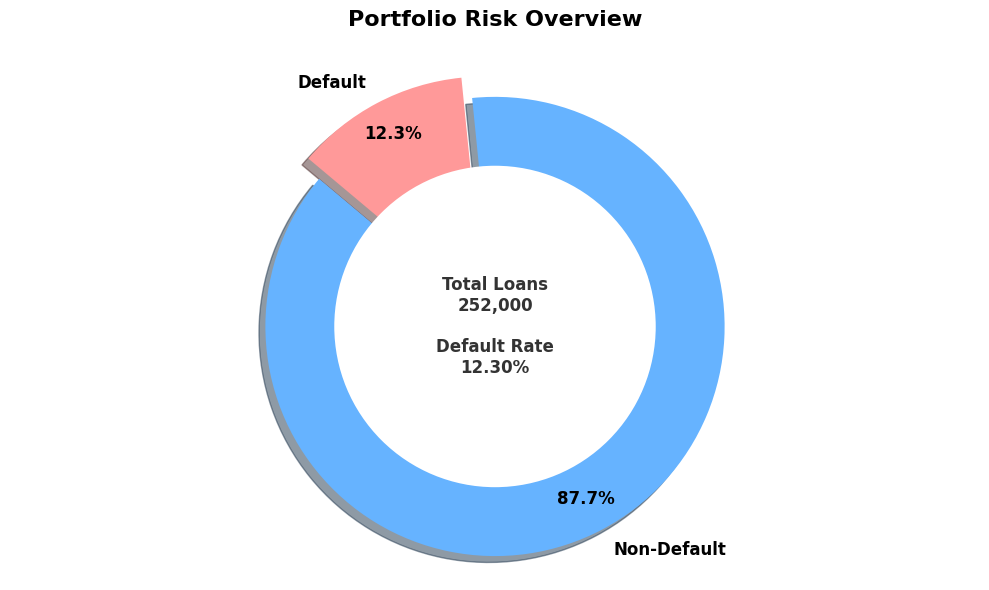

Overall Default Rate: 12.30%


In [106]:
#Chart 1: Pie Chart - Justisfication: Used it because i wanted to display categories which are less than 5. In our case i wanted to display 2 categories being defaulters and non defaulters
# Data preparation
default_counts = df["Risk_Flag"].value_counts().sort_index()
labels = ["Non-Default", "Default"]
colors = ['#66b3ff', '#ff9999']  # Professional Blue and Soft Red
explode = (0, 0.1)  # Only "explode" the Default slice to highlight it

# Calculate total and default rate for the center label
total = default_counts.sum()
default_rate = (default_counts[1] / total) * 100

plt.figure(figsize=(10, 6))

# Create the pie chart
wedges, texts, autotexts = plt.pie(
    default_counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.85,
    explode=explode,
    shadow=True,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

# Draw a circle at the center to create the "Donut" effect
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Add a text label in the center of the donut
plt.text(0, 0, f'Total Loans\n{total:,}\n\nDefault Rate\n{default_rate:.2f}%',
         ha='center', va='center', fontsize=12, fontweight='bold', color='#333333')

plt.title("Portfolio Risk Overview", fontsize=16, fontweight='bold', pad=20)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

print(f"Overall Default Rate: {default_rate:.2f}%")

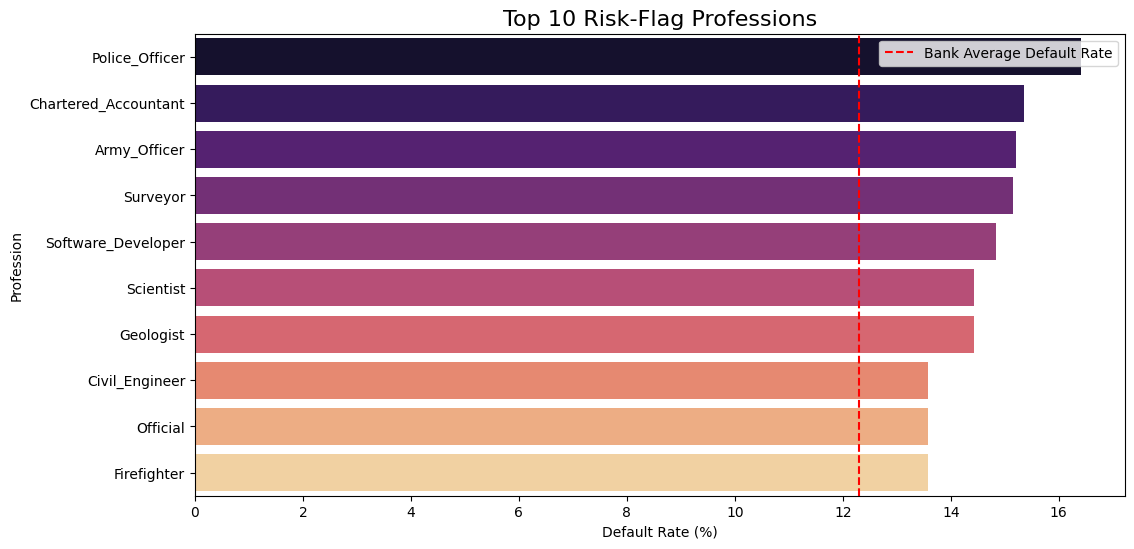

In [107]:
#chart 2: Horizontal bar chart. Justification: A bar chart was selected to visualize the Top 10 Risk Flag Professions because my objective is to compare default rates across multiple professions.
def get_job_risk_flags(df):
    # 1. Standardize text and filter out low-frequency jobs to avoid statistical noise
    # We only look at jobs with more than 30 occurrences
    job_counts = df['Profession'].value_counts()
    common_jobs = job_counts[job_counts > 30].index
    filtered_df = df[df['Profession'].isin(common_jobs)]

    # 2. Calculate the Default Rate (Risk_Flag = 1 %) per profession
    # We use normalize='index' to get percentages rather than raw counts
    risk_matrix = pd.crosstab(filtered_df['Profession'], filtered_df['Risk_Flag'], normalize='index') * 100

    # Sort by the '1' column (representing default) to find the highest risk
    high_risk_jobs = risk_matrix.sort_values(by=1, ascending=False).head(10)

    # 3. Visualization
    plt.figure(figsize=(12, 6))
    sns.barplot(x=high_risk_jobs[1], y=high_risk_jobs.index, palette='magma', hue=high_risk_jobs.index, legend=False)

    plt.axvline(df['Risk_Flag'].value_counts(normalize=True)[1] * 100,
                color='red', linestyle='--', label='Bank Average Default Rate')

    plt.title('Top 10 Risk-Flag Professions', fontsize=16)
    plt.xlabel('Default Rate (%)')
    plt.ylabel('Profession')
    plt.legend()
    plt.show()

# Run the function
get_job_risk_flags(df)

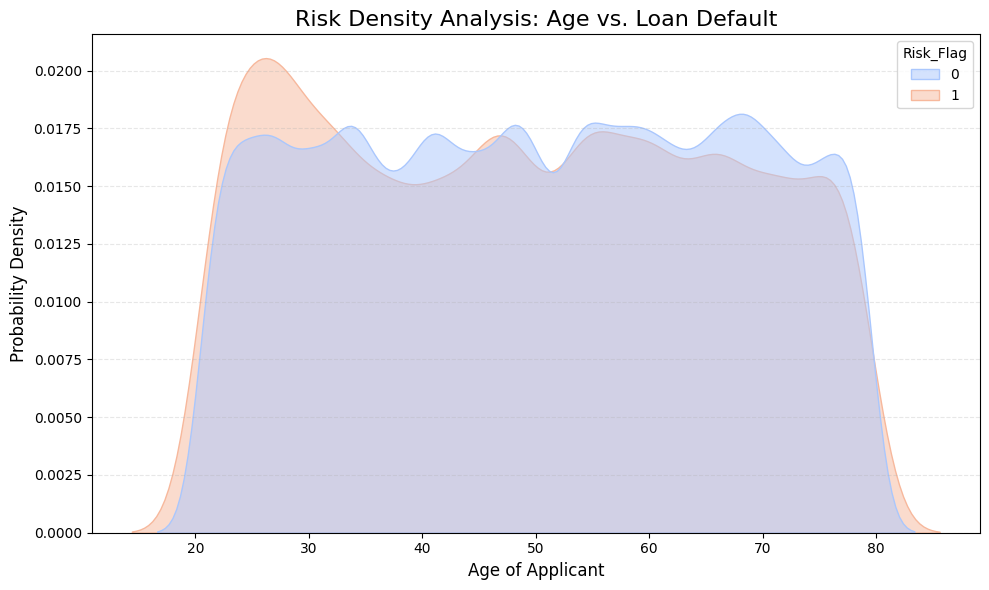

In [108]:
#chart 3: Kernel Density Estimation (KDE). Justification - i used KDE because the goal was to understand the underlying risk pattern across a continuous variable which is age.

# Filter the data to compare the two main groups: Non-Default and Default
# This assumes Risk_Flag = 0 for Non-Default and Risk_Flag = 1 for Default
comparison_df = df.copy() # Using a copy to avoid SettingWithCopyWarning if modifying later

plt.figure(figsize=(10, 6))

# common_norm=False is critical: it ensures each curve integrates to 1 independently
sns.kdeplot(data=comparison_df, x='Age', hue='Risk_Flag',
            fill=True, common_norm=False, palette='coolwarm', alpha=0.5)

# Formatting for the Board of Directors
plt.title('Risk Density Analysis: Age vs. Loan Default', fontsize=16)
plt.xlabel('Age of Applicant', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

--- Employment Stability Risk Analysis ---
Highest Risk Category: 1-3 years (15.73%)
Lowest Risk Category:  3-5 years (11.06%)
------------------------------------------


/tmp/ipykernel_248/1848913201.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=default_rates.index, y=default_rates.values, palette="mako")


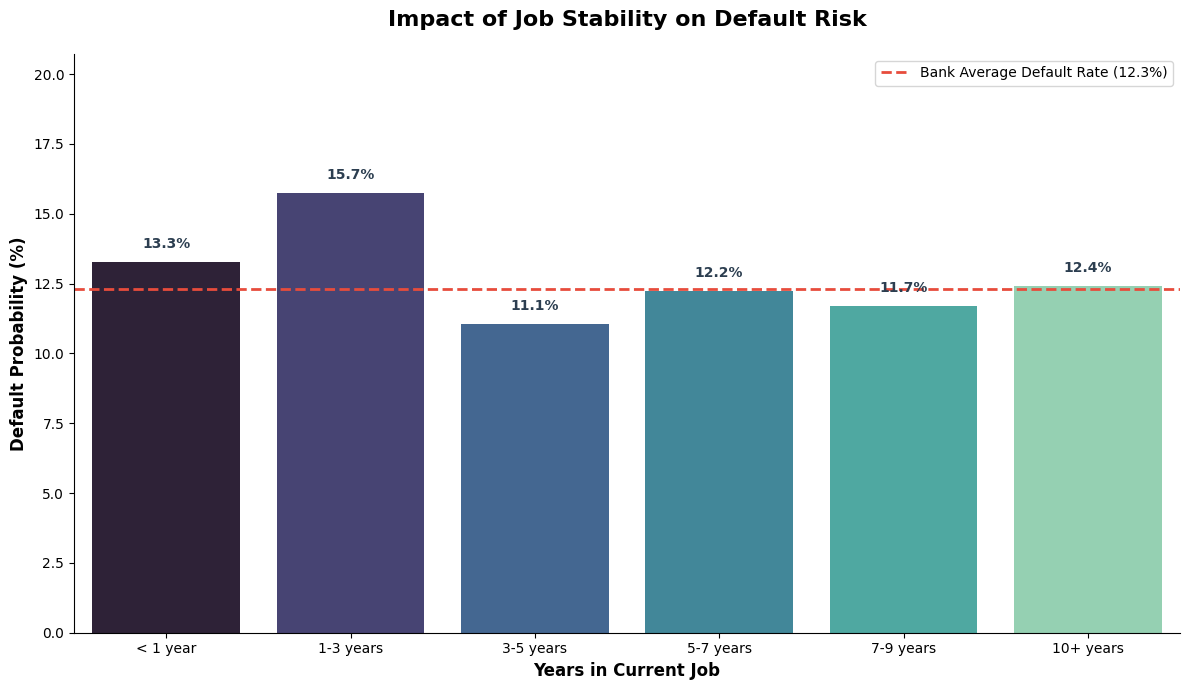

In [ ]:
#chart 4:vertical Bar Chart - Justification:i chose it to visualize the impact of years in current job on default probability because the analysis involves categorical bins derived from a continuous variable (AGE).

# Using 'right=False' means 1.0 year falls into '1-3 years', not '< 1 year'
bins = [0, 1, 3, 5, 7, 9, df['Current_Job_Yrs'].max() + 1]
labels = ['< 1 year', '1-3 years', '3-5 years', '5-7 years', '7-9 years', '10+ years']
df['Job_Yrs_Category'] = pd.cut(df['Current_Job_Yrs'], bins=bins, labels=labels, right=False)

# 2. Calculate Default Rate (Risk_Flag = 1)
emp_risk = pd.crosstab(df['Job_Yrs_Category'], df['Risk_Flag'], normalize='index') * 100
default_rates = emp_risk[1] # Extracting the '1' column (Defaults)

# 3. Print the "Most" (Highest and Lowest Risk)
print("--- Employment Stability Risk Analysis ---")
print(f"Highest Risk Category: {default_rates.idxmax()} ({default_rates.max():.2f}%)")
print(f"Lowest Risk Category:  {default_rates.idxmin()} ({default_rates.min():.2f}%)")
print("-" * 42)

# 4. Enhanced Visualization
plt.figure(figsize=(12, 7))

# Using a sequential palette (darker color = higher risk)
colors = sns.color_palette("YlGnBu", len(default_rates))
ax = sns.barplot(x=default_rates.index, y=default_rates.values, palette="mako")

# Add value labels on top of bars
for i, v in enumerate(default_rates.values):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold', color='#2c3e50')

# Benchmark Reference Line
avg_default = df['Risk_Flag'].mean() * 100
plt.axhline(avg_default, color='#e74c3c', linestyle='--', linewidth=2,
            label=f'Bank Average Default Rate ({avg_default:.1f}%)')

# Styling
plt.title('Impact of Job Stability on Default Risk', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Years in Current Job', fontsize=12, fontweight='bold')
plt.ylabel('Default Probability (%)', fontsize=12, fontweight='bold')
plt.xticks(rotation=0) # Kept at 0 for readability if labels are short
plt.ylim(0, default_rates.max() + 5) # Leave space for labels
sns.despine()

plt.legend(frameon=True, loc='upper right')
plt.tight_layout()
plt.show()

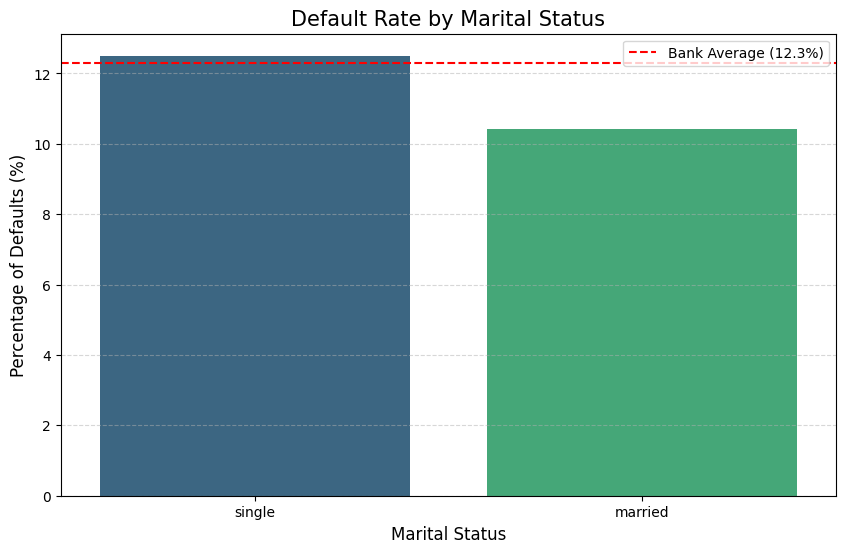

In [ ]:
#Chart 5: Bar Chart - Justification: A bar chart was chosen because the goal is to compare default rates across discrete categories—in this case, marital status (Married vs Single).

# 1. Create a cross-tabulation to calculate the percentage of defaults
# normalize='index' ensures we see the default rate % within each category
marital_risk = pd.crosstab(df['Married/Single'], df['Risk_Flag'], normalize='index') * 100

# 2. Sort by '1' (Default) rate for clear ranking
marital_risk = marital_risk.sort_values(by=1, ascending=False)

# 3. Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=marital_risk.index, y=marital_risk[1], palette='viridis', hue=marital_risk.index, legend=False)

# Add a benchmark line for the overall bank average default rate
avg_rate = (df['Risk_Flag'] == 1).mean() * 100
plt.axhline(avg_rate, color='red', linestyle='--', label=f'Bank Average ({avg_rate:.1f}%)')

plt.title('Default Rate by Marital Status', fontsize=15)
plt.xlabel('Marital Status', fontsize=12)
plt.ylabel('Percentage of Defaults (%)', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

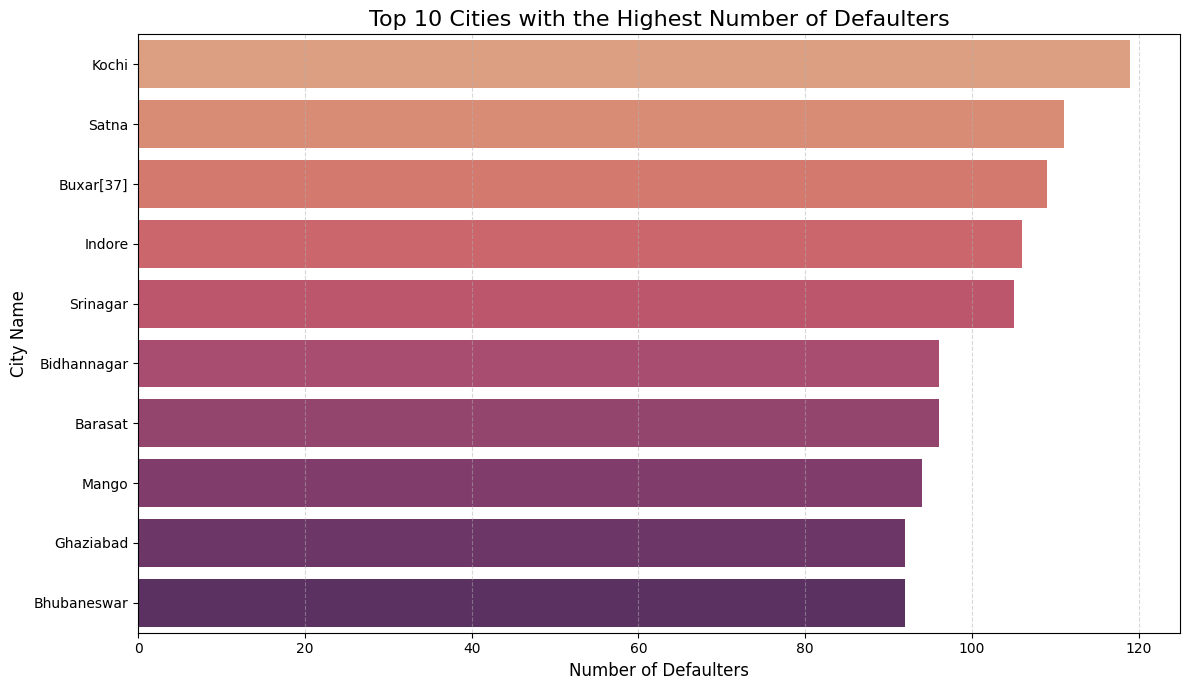

In [ ]:
#chart 6: Vertical Bar Chart - Justification: A horizontal bar chart was chosen to visualize the number of defaulted loans across cities because the objective is to rank and compare categorical data with long labels.

# 1. Filter the dataset for only defaulted loans (Risk_Flag == 1)
defaulters_only = df[df['Risk_Flag'] == 1]

# 2. Count the number of defaults per city
# We take the top 10 cities to keep the visualization clean
city_counts = defaulters_only['City'].value_counts().head(10)

# 3. Create a Horizontal Bar Chart
plt.figure(figsize=(12, 7))
sns.barplot(x=city_counts.values, y=city_counts.index, palette='flare', hue=city_counts.index, legend=False)

# Formatting
plt.title('Top 10 Cities with the Highest Number of Defaulters', fontsize=16)
plt.xlabel('Number of Defaulters', fontsize=12)
plt.ylabel('City Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

/tmp/ipykernel_248/1611670607.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_risk = df.groupby('Income_Bracket')['Risk_Flag'].mean() * 100
/tmp/ipykernel_248/1611670607.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=income_risk.index, y=income_risk.values, palette='viridis')


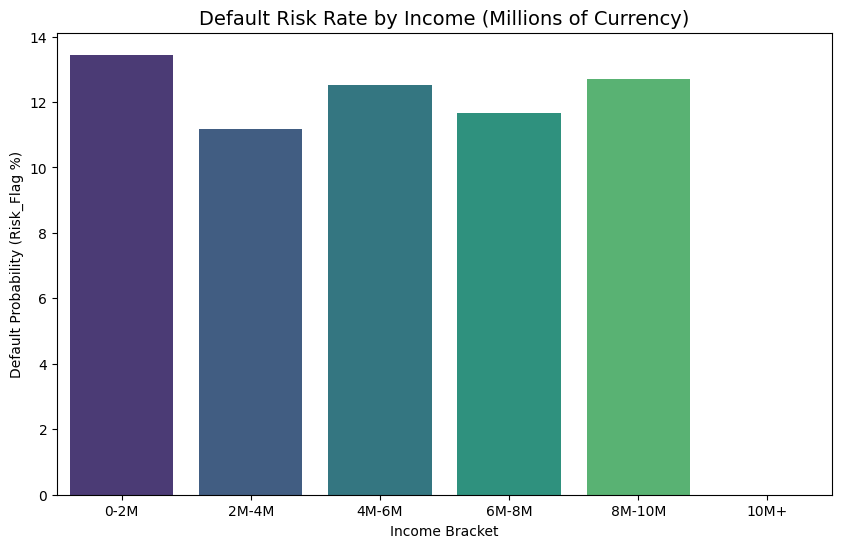

In [ ]:
#chart 7: Vertical Bar chart - Justification: A bar chart was chosen to visualize the default risk rate across income brackets because the goal is to compare discrete categories derived from a continuous variable.

# 1. Define a formatter to turn 1,000,000 into '1.0M'
def millions_formatter(x, pos):
    return f'{x / 1_000_000:.1f}M'

# 2. Create the Income Brackets (adjusting for millions)
# Bins: 0, 2M, 4M, 6M, 8M, 10M+
bins = [0, 2_000_000, 4_000_000, 6_000_000, 8_000_000, 10_000_000, float('inf')]
labels = ['0-2M', '2M-4M', '4M-6M', '6M-8M', '8M-10M', '10M+']
df['Income_Bracket'] = pd.cut(df['Income'], bins=bins, labels=labels)

# 3. Calculate Risk Rate (Risk_Flag 1 means Default)
income_risk = df.groupby('Income_Bracket')['Risk_Flag'].mean() * 100

# 4. Visualization
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=income_risk.index, y=income_risk.values, palette='viridis')

# Format the Y-axis to show percentages clearly
plt.title('Default Risk Rate by Income (Millions of Currency)', fontsize=14)
plt.ylabel('Default Probability (Risk_Flag %)')
plt.xlabel('Income Bracket')

plt.show()

/tmp/ipykernel_248/38291646.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_15_states.index, y=top_15_states['sum'], palette="rocket")


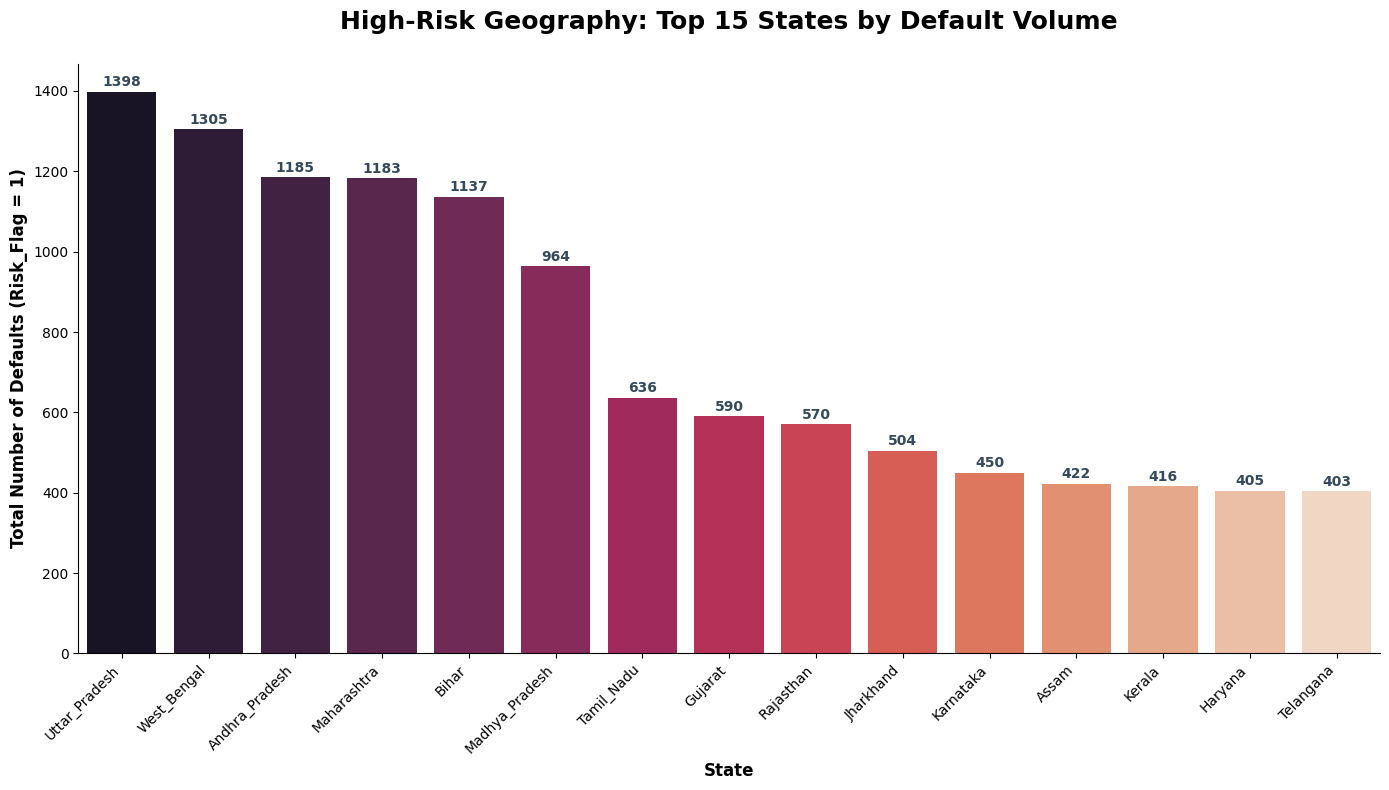

--- GEOGRAPHIC RISK SUMMARY ---
State with Highest VOLUME of Defaults: Uttar_Pradesh (1398 cases)
State with Highest RISK RATE:         Manipur (24.30%)
-------------------------------


In [ ]:
#chart 8:vertical bar chart - justification: A bar chart was selected to visualize the volume of defaults across states because the goal is to identify geographic concentration of risk and facilitate comparison.

# 1. Calculate both Volume and Rate
state_data = df.groupby("State")["Risk_Flag"].agg(['sum', 'mean']).sort_values(by='sum', ascending=False)
state_data['mean'] = state_data['mean'] * 100  # Convert to percentage
top_15_states = state_data.head(15)  # Focus on top 15 for clarity

# 2. Setup the "Dual-Insight" Visualization
plt.figure(figsize=(14, 8))

# Use a gradient palette to show intensity
ax = sns.barplot(x=top_15_states.index, y=top_15_states['sum'], palette="rocket")

# 3. Add Value Labels (The "Volume")
for i, v in enumerate(top_15_states['sum']):
    ax.text(i, v + (top_15_states['sum'].max() * 0.01), f'{int(v)}',
            ha='center', fontweight='bold', color='#34495e')

# 4. Final Styling
plt.title("High-Risk Geography: Top 15 States by Default Volume", fontsize=18, fontweight='bold', pad=25)
plt.xlabel("State", fontsize=12, fontweight='bold')
plt.ylabel("Total Number of Defaults (Risk_Flag = 1)", fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
sns.despine()

plt.tight_layout()
plt.show()

# 5. Executive Summary Printout
print("--- GEOGRAPHIC RISK SUMMARY ---")
print(f"State with Highest VOLUME of Defaults: {state_data['sum'].idxmax()} ({int(state_data['sum'].max())} cases)")
print(f"State with Highest RISK RATE:         {state_data['mean'].idxmax()} ({state_data['mean'].max():.2f}%)")
print("-" * 31)

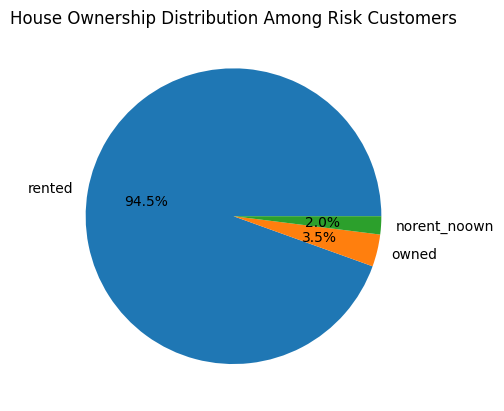

In [ ]:
#chart 9: Pie Chart - Justification: chosen because a pie chart is easy to interpret at a glance.


# Filter only risky customers

risk_only = df[df["Risk_Flag"] == 1]



# Count house ownership among risky customers

ownership_counts = risk_only["House_Ownership"].value_counts()



# Plot pie chart

plt.figure()

plt.pie(ownership_counts,

labels=ownership_counts.index,

autopct='%1.1f%%')



plt.title("House Ownership Distribution Among Risk Customers")

plt.show()

/tmp/ipykernel_248/650226838.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_cities.index, y=top_cities.values, palette='mako')


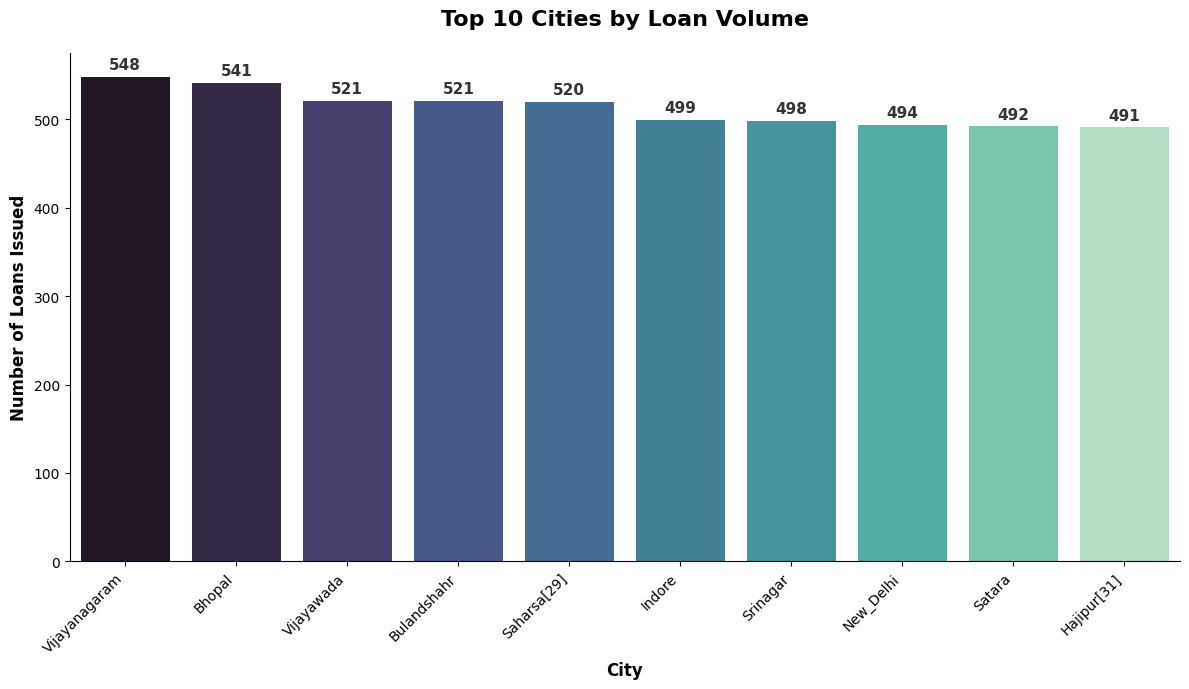

In [ ]:

#chart 10: Bar Chart - Justification: A bar chart was selected to visualize the number of loans issued across the top 10 cities because the goal is to compare discrete categories by magnitude.

# 1. Fixed the variable name and select the top 10 cities
top_cities = df["City"].value_counts().head(10)

plt.figure(figsize=(12, 7))

# 2. Use a modern color palette like 'mako' or 'viridis'
# Seaborn's barplot automatically applies a gradient for better visual appeal
ax = sns.barplot(x=top_cities.index, y=top_cities.values, palette='mako')

# 3. Add Value Labels on top of each bar
for i, v in enumerate(top_cities.values):
    ax.text(i, v + (max(top_cities.values) * 0.01), f'{v:,}',
            ha='center', va='bottom', fontsize=11, fontweight='bold', color='#333333')

# 4. Clean styling and descriptive titles
plt.title("Top 10 Cities by Loan Volume", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("City", fontsize=12, fontweight='bold')
plt.ylabel("Number of Loans Issued", fontsize=12, fontweight='bold')

# 5. Rotate labels for readability and remove chart borders
plt.xticks(rotation=45, ha='right')
sns.despine() # Removes the top and right box lines for a cleaner, modern look

plt.tight_layout()
plt.show()

In [109]:
df.head(10)

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,City,State,Current_Job_Yrs,Current_House_Yrs,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_Engineer,Rewa,Madhya_Pradesh,3,13,0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0
2,3,3991815,66,4,married,rented,no,Technical_Writer,Alappuzha,Kerala,4,10,0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1
4,5,5768871,47,11,single,rented,no,Civil_Servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1
5,6,6915937,64,0,single,rented,no,Civil_Servant,Jalgaon,Maharashtra,0,12,0
6,7,3954973,58,14,married,rented,no,Librarian,Tiruppur,Tamil_Nadu,8,12,0
7,8,1706172,33,2,single,rented,no,Economist,Jamnagar,Gujarat,2,14,0
8,9,7566849,24,17,single,rented,yes,Flight_Attendant,Kota[6],Rajasthan,11,11,0
9,10,8964846,23,12,single,rented,no,Architect,Karimnagar,Telangana,5,13,0


In [116]:
# The dataframe 'df' was corrupted by an incorrect mapping operation. To restore it to its original state for proper analysis,
# the initial data loading cell is being re-executed.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

df=pd.read_csv('/content/CSEdata.csv')

# Re-applying initial data cleaning steps after reloading df
df['Profession'] = df['Profession'].str.replace('_', ' ').str.title().str.replace(' ', '_')
df.columns = df.columns.str.title()

Features and Target

In [117]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y = df['Risk_Flag'] #target varriable


feature_columns = [
    "Income",
    "Age",
    "Experience",
    "Married/Single",
    "House_Ownership",
    "Car_Ownership",
    "Profession",
    "City",
    "State",
    "Current_Job_Yrs",
    "Current_House_Yrs"
]

X = df[feature_columns]

Encode Categorical Variables

In [118]:
X = pd.get_dummies(
    X,
    columns=[
        "Married/Single",
        "House_Ownership",
        "Car_Ownership",
        "Profession",
        "City",
        "State"
    ],
    drop_first=True
)

Split the Data

In [119]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Scale the Features

In [120]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train the Model

In [121]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

Evaluate Model

In [122]:
predictions = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, predictions))

print("\nClassification Report:")
print(classification_report(y_test, predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

Accuracy: 0.5738888888888889

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.57      0.70     44147
           1       0.17      0.62      0.27      6253

    accuracy                           0.57     50400
   macro avg       0.54      0.60      0.48     50400
weighted avg       0.82      0.57      0.65     50400


Confusion Matrix:
[[25016 19131]
 [ 2345  3908]]


Save Model Components

Save Model

In [123]:
joblib.dump(model, "loan_risk_logistic_model.pkl")

['loan_risk_logistic_model.pkl']

Save Scaler

In [126]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

Save Training Columns

In [130]:
model_columns = X_train.columns.tolist()

joblib.dump(model_columns, "model_columns.pkl")

['model_columns.pkl']

Download Model from Colab

Building the Streamlit App

In [129]:
!pip install streamlit

In [132]:
import streamlit as st
import joblib
import numpy as np
import pandas as pd

# Load trained model and scaler
model = joblib.load("loan_risk_logistic_model.pkl")
scaler = joblib.load("scaler.pkl")
model_columns = joblib.load("model_columns.pkl")

st.title("Loan Risk Prediction App")

st.write("Enter customer information to predict loan risk")

# Numeric inputs
income = st.number_input("Income")
age = st.number_input("Age")
experience = st.number_input("Experience (Years)")
current_job_yrs = st.number_input("Current Job Years")
current_house_yrs = st.number_input("Current House Years")

# Categorical inputs
married = st.selectbox("Marital Status", ["single","married"])
house = st.selectbox("House Ownership", ["rented","owned","norent_noown"])
car = st.selectbox("Car Ownership", ["no","yes"])

profession = st.text_input("Profession")
city = st.text_input("City")
state = st.text_input("State")

# Prediction button
if st.button("Predict Loan Risk"):

    input_data = pd.DataFrame({
        'Income':[income],
        'Age':[age],
        'Experience':[experience],
        'Married/Single':[married],
        'House_Ownership':[house],
        'Car_Ownership':[car],
        'Profession':[profession],
        'City':[city],
        'State':[state],
        'Current_Job_Yrs':[current_job_yrs],
        'Current_House_Yrs':[current_house_yrs]
    })

    input_data = pd.get_dummies(input_data)

    input_data = input_data.reindex(columns=model_columns, fill_value=0)

    features_scaled = scaler.transform(input_data)

    prediction = model.predict(features_scaled)

    if prediction[0] == 1:
        st.error("⚠️ High Loan Risk")
    else:
        st.success("✅ Low Loan Risk")

2026-03-09 13:42:07.351 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-09 13:42:07.355 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-09 13:42:07.356 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-09 13:42:07.362 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-09 13:42:07.366 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-09 13:42:07.367 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-09 13:42:07.373 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-09 13:42:07.380 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [134]:
# Define the Streamlit app code as a string
code = """
import streamlit as st
import pandas as pd
import joblib

# Load model files
model = joblib.load("loan_risk_logistic_model.pkl")
scaler = joblib.load("scaler.pkl")
model_columns = joblib.load("model_columns.pkl")

st.title("Loan Default Risk Prediction")

st.write("Enter customer information to predict loan default risk.")

# -------------------------
# Numeric Inputs
# -------------------------

income = st.number_input("Income", min_value=0)
age = st.number_input("Age", min_value=18)
experience = st.number_input("Work Experience (Years)", min_value=0)
current_job_yrs = st.number_input("Years in Current Job", min_value=0)
current_house_yrs = st.number_input("Years in Current House", min_value=0)

# -------------------------
# Categorical Inputs
# -------------------------

married = st.selectbox("Marital Status", ["single","married"])
house = st.selectbox("House Ownership", ["rented","owned","norent_noown"])
car = st.selectbox("Car Ownership", ["no","yes"])

profession = st.text_input("Profession")
city = st.text_input("City")
state = st.text_input("State")

# -------------------------
# Prediction
# -------------------------

if st.button("Predict Loan Risk"):

    input_data = pd.DataFrame({
        'Income':[income],
        'Age':[age],
        'Experience':[experience],
        'Married/Single':[married],
        'House_Ownership':[house],
        'Car_Ownership':[car],
        'Profession':[profession],
        'City':[city],
        'State':[state],
        'Current_Job_Yrs':[current_job_yrs],
        'Current_House_Yrs':[current_house_yrs]
    })

    # One-hot encode
    input_data = pd.get_dummies(input_data)

    # Align columns with training data
    input_data = input_data.reindex(columns=model_columns, fill_value=0)

    # Scale features
    input_scaled = scaler.transform(input_data)

    # Predict
    prediction = model.predict(input_scaled)
    probability = model.predict_proba(input_scaled)[0][1]

    # Output result
    if prediction[0] == 1:
        st.error(f"⚠️ High Loan Default Risk (Probability: {probability:.2f})")
    else:
        st.success(f"✅ Low Loan Default Risk (Probability: {probability:.2f})")

"""

# Create requirements.txt for the app
with open("requirements.txt", "w") as f:
    f.write("streamlit\n")
    f.write("numpy\n")
    f.write("pandas\n")
    f.write("scikit-learn\n")
    f.write("joblib\n")

# Create Streamlit app file
with open("app.py", "w") as f:
    f.write(code)

Confirm app.py Was Created

In [ ]:
!ls

app.py	     loan_risk_logistic_model.pkl  requirements.txt  scaler.pkl
CSEdata.csv  model_columns.pkl		   sample_data


Create requirements.txt

In [ ]:
with open("requirements.txt", "w") as f:
    f.write("""streamlit
pandas
numpy
scikit-learn
joblib""")

Test the App Locally

In [ ]:
!streamlit run app.py




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.240.235.156:8501

